In [27]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../sample_data/wine_data.csv',header= None,usecols = [0,1,2])
df.columns = ['Class label','Alcohol','Malic acid']

In [19]:
df.head()
df.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

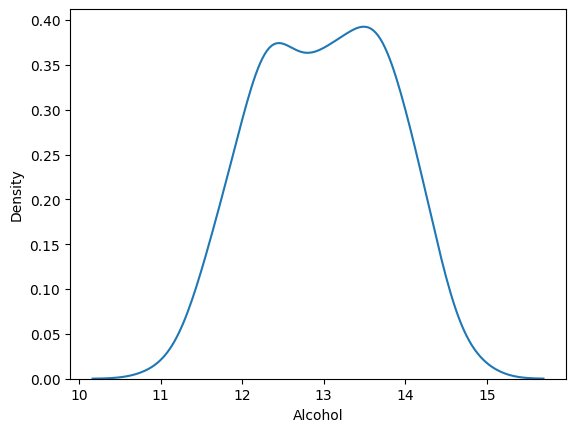

In [8]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

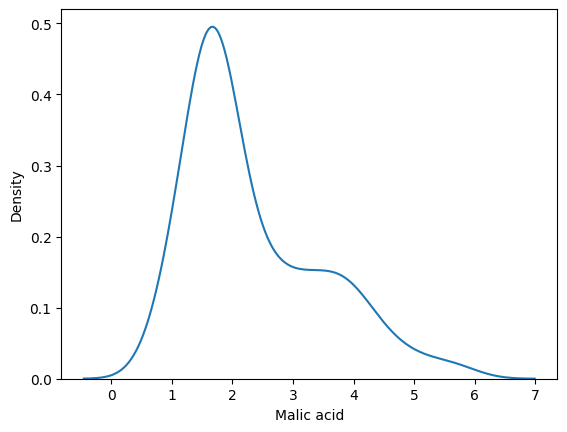

In [10]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

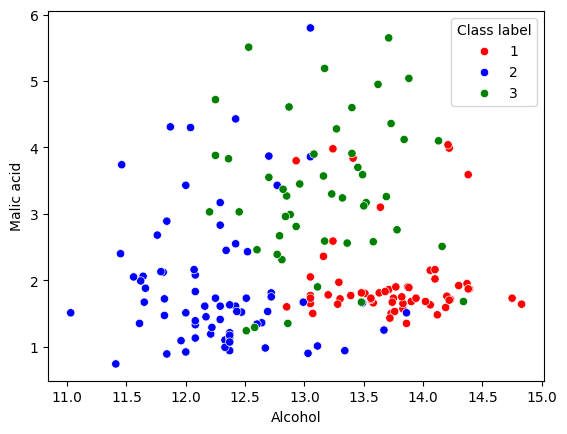

In [14]:
color_dict = {1:'red',2:'blue',3:'green'}
sns.scatterplot(x=df['Alcohol'],y = df['Malic acid'],hue = df['Class label'],palette=color_dict)

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Class label',axis = 1),df['Class label'],test_size = 0.2,random_state = 42)

In [18]:
x_train.shape , x_test.shape

((142, 2), (36, 2))

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_scale = scaler.transform(x_train)
x_test_scale = scaler.transform(x_test)

In [21]:
x_train_scaled = pd.DataFrame(x_train_scale,columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scale,columns = x_test.columns)

In [23]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,142.000000,142.000000
mean,0.512917,0.302143
std,0.215820,0.232980
min,0.000000,0.000000
25%,0.342763,0.147658
50%,0.521053,0.200611
75%,0.696711,0.457230
max,1.000000,1.000000


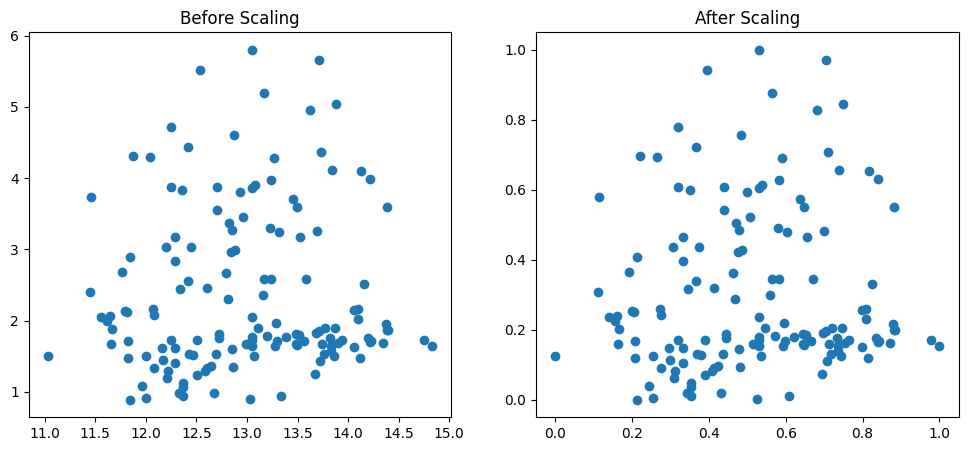

In [29]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))

ax1.set_title('Before Scaling')
ax1.scatter(x_train['Alcohol'],x_train['Malic acid'])

ax2.set_title('After Scaling')
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic acid'])
plt.show()

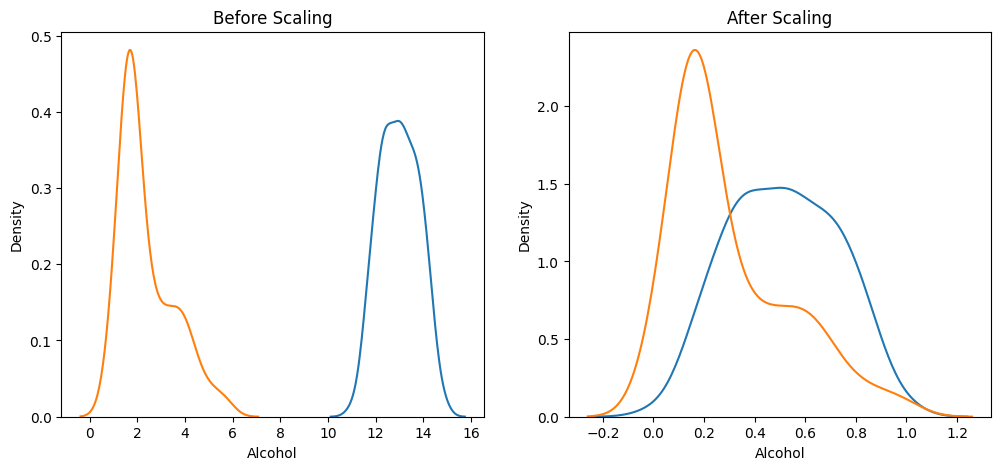

In [30]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic acid'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'],ax=ax2)
plt.show()